# 2D Segmentation with the Datamint Trainer API

This notebook shows how to train a **UNet++ semantic segmentation** model on the **BUSI** (Breast Ultrasound Images) dataset using Datamint's **Trainer API** — a high-level wrapper that handles dataset loading, model creation, training, experiment tracking, and model registration from a small amount of code.

## Comparison with the manual Workflow

The conventional way requires you to:
1. Define transforms, loss function, metrics, and a full LightningModule (~150 lines)
2. Configure MLflow logger, callbacks, and Trainer (~50 lines)
3. Build and wire together `DatamintDataModule`, `L.Trainer`, etc.

With the Trainer API, **all of that is replaced by ~3 lines**:

```python
from datamint.lightning.trainers import UNetPPTrainer

trainer = UNetPPTrainer(project='MyProject')
results = trainer.fit()
```

## What You'll Learn

1. Upload data to Datamint
2. Train with `UNetPPTrainer` using **zero configuration**
3. Train with `SemanticSegmentation2DTrainer` while swapping in a custom external model
4. Visualise predictions
5. Register and deploy the trained model

## Required Dependencies

```bash
pip install datamint
```

In [1]:
from datamint import Api

PROJECT_NAME = "UNetPP_Segmentation_Tutorial"
api = Api()

## 1. Setup: Create Project

Create (or retrieve) a Datamint project for this tutorial.

In [2]:
proj = api.projects.create(
    name=PROJECT_NAME,
    description="Tutorial project for UNet++ segmentation on BUSI dataset",
    exists_ok=True # Just return the existing project if it already exists
)
proj

UNetPP_Segmentation_Tutorial
2025-12-23T14:33:11.807Z
datamint-dev@mail.com
False
780
0
Tutorial project for UNet++ segmentation on BTCV dataset


## 2. Dataset Preparation: Download and Upload BUSI

This section downloads the BUSI dataset and uploads it to Datamint.
If you already have the data inside Datamint, you can **skip to Section 3**.

In this section, we will:
- Download the BUSI dataset
- Upload ultrasound images to Datamint
- Upload corresponding segmentation masks
- Create train/val/test splits

### 2.1 Download BUSI Dataset

The BUSI dataset is available from Kaggle. For this tutorial, we'll use the breast ultrasound images dataset.

> Al-Dhabyani W, Gomaa M, Khaled H, Fahmy A. Dataset of breast ultrasound images. Data in Brief. 2020 Feb;28:104863. DOI: 10.1016/j.dib.2019.104863.

In [ ]:
import os
import requests
import zipfile
from pathlib import Path

BUSI_URL = "https://www.kaggle.com/api/v1/datasets/download/sabahesaraki/breast-ultrasound-images-dataset"
DATA_DIR = Path("/tmp/BUSI_dataset")

if not DATA_DIR.exists():
    print("Downloading BUSI dataset...")
    response = requests.get(BUSI_URL, stream=True)
    response.raise_for_status()
    zip_path = DATA_DIR / "Dataset_BUSI.zip"
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    with open(zip_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    os.remove(zip_path)
    print("Download complete!")
else:
    print(f"Dataset already exists at {DATA_DIR}")

### 2.2 Find image and mask paths

In [ ]:
base_dir = DATA_DIR / "Dataset_BUSI_with_GT"
classes = ["benign", "malignant", "normal"]

image_paths = []
label_paths = []

for cls in classes:
    cls_dir = base_dir / cls
    cls_images = sorted([p for p in cls_dir.glob("*.png") if "_mask" not in p.name])
    for img_p in cls_images:
        mask_p = cls_dir / f"{img_p.stem}_mask.png"
        if mask_p.exists():
            image_paths.append(img_p)
            label_paths.append(mask_p)

print(f"Found {len(image_paths)} images and {len(label_paths)} masks")

### 2.3 Upload images and masks to Datamint

In [ ]:
# Upload images
uploaded_resources = api.resources.upload_resources(
    [str(p) for p in image_paths],
    tags=['busi', 'ultrasound', 'breast'],
    publish_to=proj,
    progress_bar=True,
)
print(f"Uploaded {len(uploaded_resources)} images")

In [ ]:
from tqdm.auto import tqdm

# Get resources from project
all_resources = list(api.resources.get_list(project_name=PROJECT_NAME, tags=['busi']))
filename_to_resource = {r.filename: r for r in all_resources}

# Upload segmentation masks
for img_path, label_path in tqdm(zip(image_paths, label_paths), total=len(image_paths)):
    if 'normal' in img_path.parent.name:
        continue  # Normal images have no lesion masks
    resource = filename_to_resource[img_path.name]
    cls_name = img_path.parent.name  # 'benign' or 'malignant'

    api.annotations.upload_segmentations(
        resource=resource,
        file_path=label_path,
        name=cls_name,
        imported_from="Original GT BUSI Dataset",
    )

print("Segmentation masks uploaded successfully!")

### 2.4 Tag train/val/test splits

We split the dataset into three subsets using tags for reproducibility.

| Split | Percentage | Purpose |
|-------|------------|---------|
| Train | 70% | Model training |
| Validation | 15% | Hyperparameter tuning, early stopping |
| Test | 15% | Final model evaluation |

In [ ]:
import random

all_resources = list(api.resources.get_list(project_name=PROJECT_NAME, tags=['busi']))
all_resources.sort(key=lambda r: r.filename)

random.seed(42)
random.shuffle(all_resources)

n_total = len(all_resources)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

train_resources = all_resources[:n_train]
val_resources = all_resources[n_train:n_train + n_val]
test_resources = all_resources[n_train + n_val:]

api.projects.assign_splits(proj, train_resources, split_name='train')
api.projects.assign_splits(proj, val_resources, split_name='val')
api.projects.assign_splits(proj, test_resources, split_name='test')

print(f"Train: {len(train_resources)}, Val: {len(val_resources)}, Test: {len(test_resources)}")

## 3. Training with the Trainer API

This is where the **Trainer API** shines. Instead of manually defining:
- A dataset with the correct flags
- Augmentation pipelines
- A LightningModule with loss, metrics, optimizer
- Callbacks, loggers, and a Lightning Trainer
- A deployment adapter

...you simply create a `UNetPPTrainer` (or `SemanticSegmentation2DTrainer`) and call `fit()`.

The trainer automatically:
1. Builds an `ImageDataset` configured for semantic segmentation
2. Creates augmentation pipelines (with medical-image-specific augmentations for `UNetPPTrainer`)
3. Instantiates a default segmentation model when `model=None`
4. Sets up **BCE + Dice loss**, **IoU** and **Dice** metrics
5. Configures MLflow logging, checkpointing, and early stopping
6. Trains and evaluates on the test split

In [ ]:
from datamint.lightning import UNetPPTrainer

trainer = UNetPPTrainer(
    project=PROJECT_NAME,
    image_size=256,
    batch_size=16,
    max_epochs=12,
    early_stopping_patience=10,
    accelerator='auto',
    # register_model_name='MyModelName' # Default is project name
)

In [ ]:
results = trainer.fit()

That's it! The entire training pipeline — from dataset loading to model deployment — in **3 lines of code**.

Let's inspect the results:

In [ ]:
# Inspect the results dictionary
print("Test results:")
for metric_dict in results['test_results']:
    for k, v in metric_dict.items():
        print(f"  {k}: {v:.4f}")

### 3.1 Using a custom or external model

You can keep the Datamint trainer workflow and swap only the model architecture.

There are two supported patterns:
1. (**RECOMMENDED**) Pass a `SegmentationModule` subclass **class** to `model=`. This is the preferred path when you want Datamint to manage computing loss and metrics, and when you want the resulting model to remain Datamint-compatible for inference and deployment. In this case, pass the class, not the instance object.
2. Pass a fully constructed `lightning.LightningModule` **instance** to `model=` when you want complete control over `training_step`, `validation_step`, `test_step`, and `configure_optimizers`.

The example below uses `DeepLabV3Plus` from `segmentation_models_pytorch` as an external architecture while still keeping the Datamint trainer workflow.

In [ ]:
from datamint.lightning import SemanticSegmentation2DTrainer
from datamint.lightning.trainers.lightning_modules import SegmentationModule
import segmentation_models_pytorch as smp


class MyCustomSegModel(SegmentationModule):
    def __init__(self, *args, **kwargs):
        super().__init__(*args,
                         class_names=['benign', 'malignant'],
                         **kwargs)
        self.model = smp.UnetPlusPlus(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=3,
            classes=2,
        )  # or load a pretrained model, etc.

    def forward(self, x):
        return self.model(x)

    # OPTIONAL: Override test_step for custom behaviour
    def test_step(self, batch: dict, batch_idx: int):
        # # Optionally override test_step for custom behavior during testing
        # images = batch['image']  # shape: (BatchSize, 3, H, W)
        # masks = batch['segmentations']  # shape: (BatchSize, NumClasses+1, H, W) # +1 because of the "background" class

        # (...) custom test logic, e.g. compute additional metrics, log images, etc.
        # loss = self.criterion(self(images), masks)
        # custom_metrics = compute_custom_metrics(logits, masks)
        # self.log('test/loss', custom_metrics) # IMPORTANT
        # self.log('test/custom_metric', custom_metrics)
        # (...)

        # For now, just call the default test_step
        return super().test_step(batch, batch_idx)


trainer = SemanticSegmentation2DTrainer(
    project=PROJECT_NAME,
    image_size=256,
    batch_size=16,
    early_stopping_patience=10,
    model=MyCustomSegModel,  # You can also pass an instance of MyCustomSegModel() if you prefer
    accelerator='auto',  # automatically use GPU if available, otherwise CPU
    # register_model_name='MyModelName' # Default is project name
)

In [ ]:
results = trainer.test(register_model=True) # automatically saves the model into Datamint's server

In [ ]:
# Inspect the results dictionary
print("Test results:")
for metric_dict in results:
    for k, v in metric_dict.items():
        print(f"  {k}: {v:.4f}")

Getting results after restarting the kernel...

In [ ]:
import mlflow
from mlflow import MlflowClient

model_uri = "models:/UNetPP_Segmentation_Tutorial/latest"

model_info = mlflow.models.get_model_info(model_uri)
client = MlflowClient()
run = client.get_run(model_info.run_id)
metrics = run.data.metrics

print(f"Metrics for {model_uri}:")
for metric_name, value in metrics.items():
    print(f" - {metric_name}: {value}")

You can always retrieve the trained model instance from the trainer at `trainer.model`.

When the model inherits from `SegmentationModule`, the registered artifact already has Datamint-compatible prediction behaviour.

### 3.2 Local Inference

In [ ]:

import mlflow
from datamint.mlflow import flavors as datamint_flavor
from datamint.entities.resource import LocalResource

r = trainer.dataset[0]['resource']

model_loaded = datamint_flavor.load_model('models:/UNetPP_Segmentation_Tutorial/latest')
model_loaded.predict([r])

# Alternatively:
# model_loaded = mlflow.pyfunc.load_model('models:/UNetPP_Segmentation_Tutorial/latest')
# model_loaded.predict([r])

## 4. Visualize predictions

Let's visualize the model predictions against ground truth on test samples.

Sample 64 — IoU: 86.0% — Classes: ['benign', 'malignant']
Sample 58 — IoU: 88.3% — Classes: ['benign', 'malignant']
Sample 74 — IoU: 33.0% — Classes: ['benign', 'malignant']


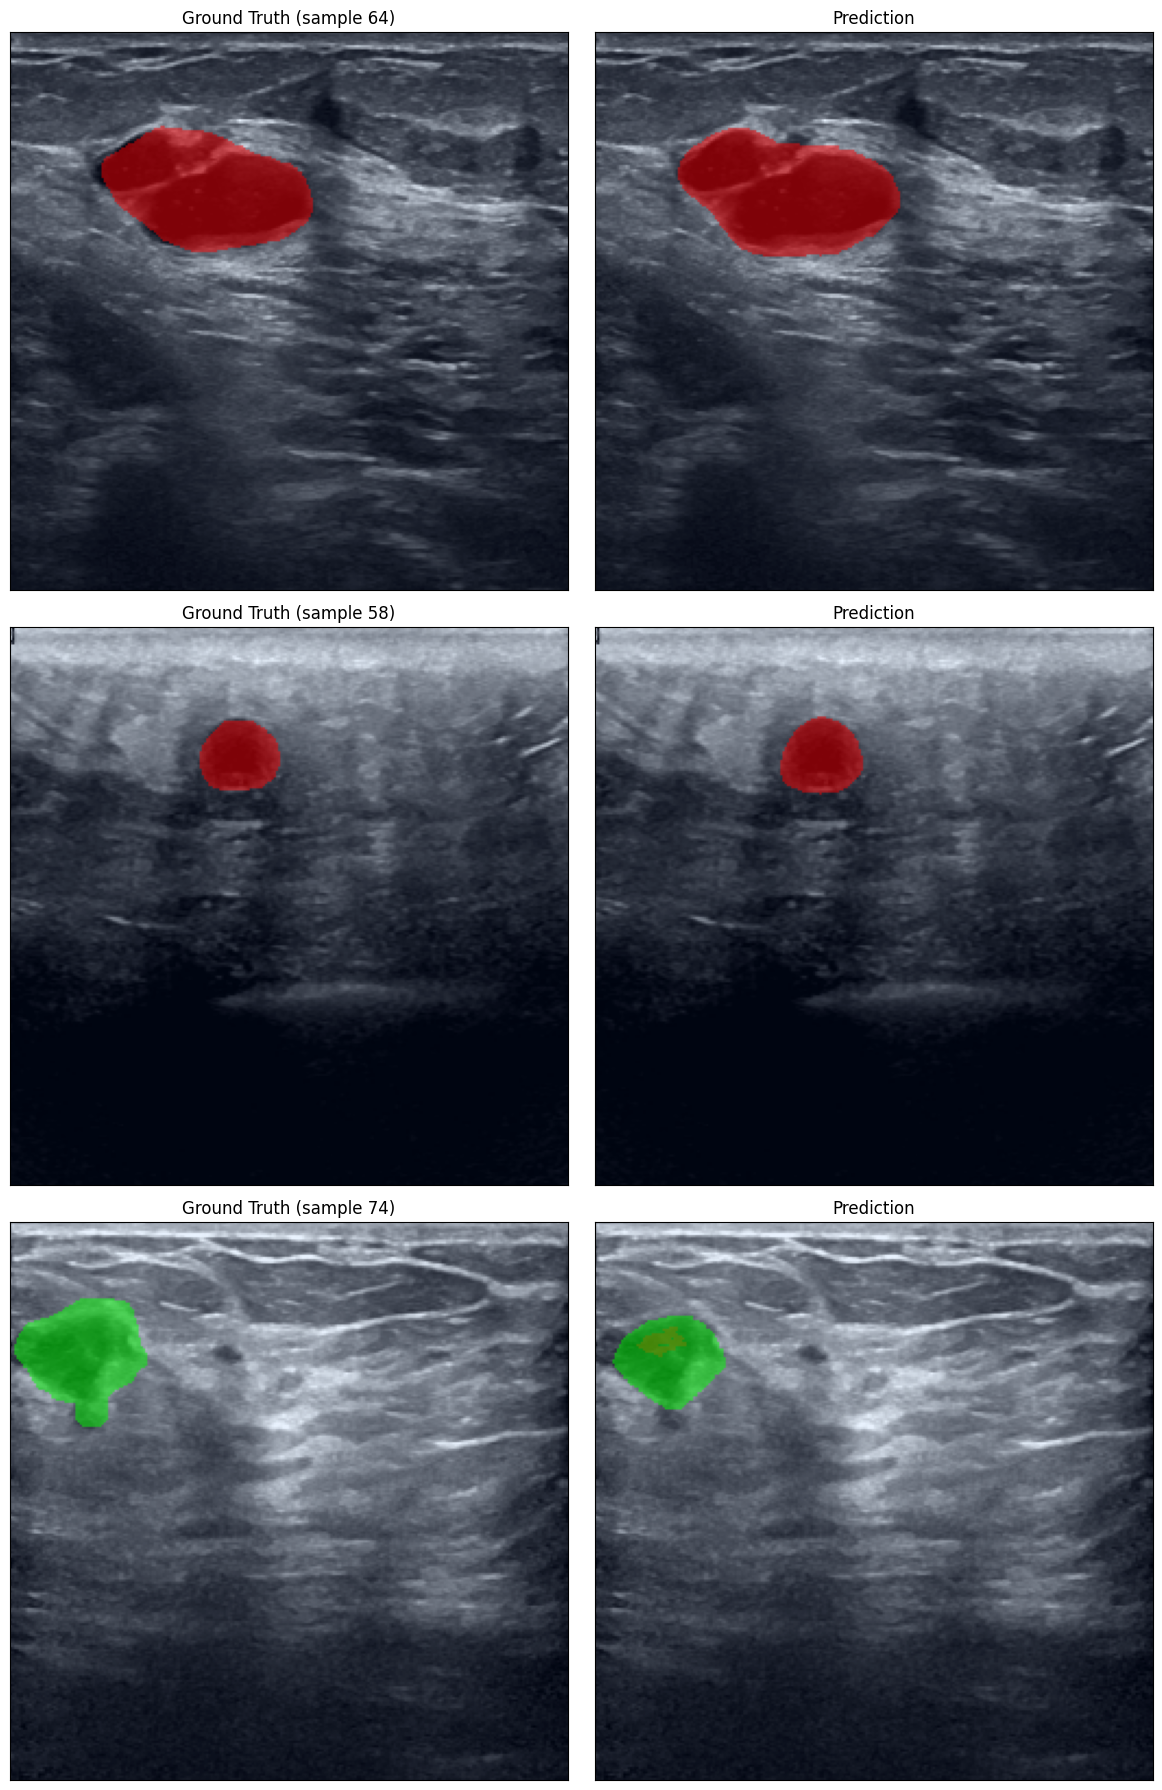

In [15]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from datamint.utils.visualization import show, draw_masks
from torchmetrics.functional.segmentation import mean_iou

model = trainer.model
model.eval()

# Access the test dataset from the internal datamodule
test_dataset = trainer.datamodule.test_dataloader().dataset
class_names = trainer.datamodule.dataset.seglabel_list

fig, axes = plt.subplots(3, 2, figsize=(12, 18))

for row in range(3):
    idx = np.random.choice(len(test_dataset))
    sample = test_dataset[idx]
    image = sample['image']         # (C, H, W)
    mask_gt = sample['segmentations']  # (#classes+1, H, W) — includes background

    with torch.inference_mode():
        logits = model(image.unsqueeze(0).to(model.device))
        mask_pred = (logits[0] > 0).cpu()

    # Ground truth (skip background channel)
    gt_overlay = draw_masks(image, mask_gt[1:], alpha=0.5)
    axes[row, 0].set_title(f"Ground Truth (sample {idx})")
    show(gt_overlay, ax=axes[row, 0])

    # Prediction
    pred_overlay = draw_masks(image, mask_pred, alpha=0.5)
    axes[row, 1].set_title("Prediction")
    show(pred_overlay, ax=axes[row, 1])

    iou = mean_iou(
        mask_pred.unsqueeze(0).long(),
        mask_gt[1:].unsqueeze(0).long(),
        num_classes=len(class_names),
        input_format='one-hot',
    )
    print(f"Sample {idx} — IoU: {iou.max():.1%} — Classes: {class_names}")

plt.tight_layout()
plt.show()

## 5. Customization options

The Trainer API is customizable at several layers. Here are the most common overrides:

### 5.1 Change the encoder backbone

Use any encoder supported by [segmentation_models_pytorch](https://github.com/qubvel-org/segmentation_models.pytorch):

```python
trainer = UNetPPTrainer(
    project=PROJECT_NAME,
    encoder_name='efficientnet-b4',  # Larger encoder
    image_size=384,                  # Higher resolution
    batch_size=8,                    # Smaller batch for larger model
)
```

### 5.2 Custom transforms and loss

```python
import albumentations as A
from albumentations.pytorch import ToTensorV2

my_transforms = A.Compose([
    A.Resize(512, 512),
    A.CLAHE(p=0.3),
    A.Normalize(),
    ToTensorV2(),
])

trainer = UNetPPTrainer(
    project=PROJECT_NAME,
    train_transform=my_transforms,
    loss_fn=torch.nn.BCEWithLogitsLoss(),
)
```

### 5.3 Pass extra Lightning Trainer arguments

```python
trainer = UNetPPTrainer(
    project=PROJECT_NAME,
    trainer_kwargs={
        'precision': '16-mixed',      # Mixed precision training
        'gradient_clip_val': 1.0,     # Gradient clipping
        'accumulate_grad_batches': 4, # Gradient accumulation
    },
)
```

### 5.4 Custom model arch and Datamint-compatible model

When you want a different architecture but still want the trainer to own the loss, metrics, MLflow model behaviour, and deployment path, subclass `SegmentationModule` and pass the class to `model=`:

```python
from datamint.lightning.trainers.lightning_modules import SegmentationModule
import segmentation_models_pytorch as smp

class MyCustomSegModel(SegmentationModule):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, class_names=['benign', 'malignant'], **kwargs)
        self.model = smp.DeepLabV3Plus(
            encoder_name='resnet50',
            encoder_weights='imagenet',
            in_channels=3,
            classes=2,
        )

    def forward(self, x):
        return self.model(x)

trainer = SemanticSegmentation2DTrainer(
    project=PROJECT_NAME,
    model=MyCustomSegModel,
    image_size=256,
)
```

Passing the class object lets the trainer inject `loss_fn` and `metrics_factories`.

### 5.5 Use a fully custom LightningModule

If you already have your own Lightning module, pass an instance. In this mode you own the training and evaluation logic:

```python
import lightning as L
import torch
import segmentation_models_pytorch as smp

class MyCustomModule(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = smp.DeepLabV3Plus(
            encoder_name='resnet50',
            encoder_weights='imagenet',
            in_channels=3,
            classes=2,
        )
        self.loss_fn = torch.nn.BCEWithLogitsLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images = batch['image']
        masks = batch['segmentations'][:, 1:].float()
        loss = self.loss_fn(self(images), masks)
        self.log('train/loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        images = batch['image']
        masks = batch['segmentations'][:, 1:].float()
        loss = self.loss_fn(self(images), masks)
        self.log('val/loss', loss)
        return loss

    def test_step(self, batch, batch_idx):
        images = batch['image']
        masks = batch['segmentations'][:, 1:].float()
        loss = self.loss_fn(self(images), masks)
        self.log('test/loss', loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-4)

trainer = SemanticSegmentation2DTrainer(
    project=PROJECT_NAME,
    model=MyCustomModule(),
)
```

This still works with Datamint datasets, splits, MLflow logging, and checkpointing. The tradeoff is that a plain `LightningModule` does not automatically gain Datamint-native prediction methods for deployment. When you need Datamint-native serving, prefer `SegmentationModule` or wrap the final model in a `DatamintModel`.

## 6. Deployment

The trainer **automatically** created and registered a deployment adapter in MLflow.
You can deploy it directly to the Datamint server:

In [ ]:
job = api.deploy.start(
    model_name=PROJECT_NAME,
    model_alias="latest",
    with_gpu=False,
)

print(f"Deployment job started!")
print(f"Job ID: {job.id}")
print(f"Status: {job.status}")

In [ ]:
# Check deployment status
job = api.deploy.get_by_id(job.id)

print(f"Job Status: {job.status}")
print(f"Progress: {job.progress_percentage}%")

if job.error_message:
    print(f"Error: {job.error_message}")

### 6.1 Remote inference

In [ ]:
from datamint import Api
PROJECT_NAME = "UNetPP_Segmentation_Tutorial"
api = Api()

In [ ]:
r = api.resources.get_list(project_name=PROJECT_NAME, limit=1)[0]

In [ ]:
inf_job = api.inference.submit(
    model_name=PROJECT_NAME,
    model_alias="latest",
    resource_id=r.id
)
inf_job.wait() # Wait for inference to complete

visualize predictions:

In [ ]:
from matplotlib import pyplot as plt

# plot all predictions using matplotlib
preds = inf_job.predictions[0]
plt.figure(figsize=(6, 6))
plt.imshow(preds[0].mask, cmap='gray')
plt.title("Predicted Mask")
plt.axis('off')

In [ ]:
# Open the Datamint dashboard for this project
proj.show()

## Summary: What the Trainer API Automates

The Trainer API automatically handles the full segmentation workflow, including:

- Dataset loading and setup
- Semantic segmentation configuration
- Medical-image augmentation pipelines
- Model creation with a pretrained encoder
- Loss function setup
- Metric configuration
- Lightning trainer setup
- Callbacks, checkpointing, and early stopping
- MLflow experiment tracking
- Test-time evaluation
- Deployment adapter creation

This keeps the training workflow concise while still allowing customization through custom models, transforms, loss functions, and trainer arguments.